# `DiscreteControlLoopSimulator` demo

This notebook demonstrates `dynestyx.control.DiscreteControlLoopSimulator`, which implements the discrete-time online control loop under the `previous_transition` convention:

$$
\begin{aligned}
& \text{Times} = [t_0, \dots, t_{N}]\\
&x_0 \sim p_0, \quad \hat{p}_0 = p_0 \quad \text{Initialization step} \\
&\text{for $k = 0,\dots N-1$}:\\
&u_{k}, s_{k+1} =\pi(\hat{p}_{k}, t_{k}, t_{k+1}, s_k) \quad \text{Select the control}\\
&x_{k+1} \sim p(x_{k+1} \mid x_k, u_k, t_k, t_{k+1}) \quad \text{State transition} \\
&y_{k+1} \sim p(y_{k+1} \mid x_{k+1}, u_k, t_{k+1}) \quad \text{emit observation}\\
&\hat{p}_{k+1} = \text{FilterUpdate}(y_{k+1}, \hat{p}_k, u_k) \quad \text{Update the filtering distribution using the observation} \\
\end{aligned}
$$

This is the `previous_transition` convention because both the state $x_{k}$ and the observation $y_{k}$ use the control chosen at the previous step $u_{k-1}$. This is in opposition to the `same_time` convention, where $y_k$ depend on $u_{k}$. Note that this second convention is not yet available for close loop control. As a result of this convention, the observation $y_0$ never exists. 

We use:
1. a simple 1D linear-Gaussian dynamical system (a noisy random walk, `x_{k+1} = A x_k + B u_k + noise`) with the full state directly observed under Gaussian noise,
2. a linear feedback policy `u_k = -K x_hat_k` that drives the state toward 0,
3. a plot comparing the controlled trajectory against an uncontrolled (`K=0`) baseline.

In [7]:
import dynestyx as dsx
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpyro.distributions as dist

from dynestyx.inference.configs.filter import KFConfig
from dynestyx.models import DynamicalModel
from dynestyx.models.observations import LinearGaussianObservation
from dynestyx.models.state_evolution import LinearGaussianStateEvolution

## 1 Simple linear dynamics

`state_dim = control_dim = observation_dim = 1`. The transition is 
$$
x_{k+1} = ax_k + u_k + \eta_k,
$$
with $a=1.05$, is linear with additive Gaussian noise. Without control, this system is unstable and $x_k \rightarrow \infty$ (when $x_0 >0$).
The observation model is 
$$
y_k = x_k + \sigma\varepsilon_k
$$
$\sigma=0.2$, observes the full state under additive Gaussian noise. We define the dynamics in the usual dynestyx way.

In [8]:
state_dim = control_dim = obs_dim = 1

dynamics = DynamicalModel(
    initial_condition=dist.MultivariateNormal(jnp.array([5.0]), 0.1 * jnp.eye(state_dim)),
    state_evolution=LinearGaussianStateEvolution(
        A=jnp.array([[1.05]]), B=jnp.array([[1.0]]), cov=0.05 * jnp.eye(state_dim)
    ),
    observation_model=LinearGaussianObservation(
        H=jnp.eye(obs_dim, state_dim), R=0.2 * jnp.eye(obs_dim)
    ),
    control_dim=control_dim,
)

## 2. Defining a controller

The control loop requires the policy to be any callable (for example, a learned neural policy or a model-predictive controller) that accepts four arguments:

* `x_hat` a numpyro distribution representing the filtering distribution (depends on the filter).
* `t_now` the current time.
* `t_next` the next time at which the dynamics will advance.
* `s` internal state. An initial state can optionally be passed to the simulator

It must return 
* A control `u`, a `jax.numpy.array`.
* A new state `s`.


Here we implement a simple linear-feedback policy $\pi(\hat{x}) = -K \hat{x}$ as an `equinox.Module`.

With `a - b*k = 1.05 - 0.5 = 0.55`, well inside the unit circle, the closed loop should converge to 0.

In [9]:
class LinearPolicy(eqx.Module):
    K: jnp.ndarray

    def __call__(self, x_hat, t_now, t_next, s): # here t_now, t_next and s are unused, but they are passed in by the simulator
        return -self.K @ x_hat.mean, s # here we only use the mean of the distribution

## 3. Run the closed loop, with and without control

`dsx.simulate(dynamics, rng_key=key, predict_times=..., control_policy=policy, filter_config=...)` runs the closed loop directly

`filter_config=KFConfig(filter_source="cuthbert", record_filtered_states_mean=True)` makes the filtered state estimate available as an output (it is needed internally either way; this only controls whether it is also returned). We run twice with the same key: once with the stabilizing gain `K=0.5`, once with `K=0` (no control) as a baseline.

In [10]:
predict_times = jnp.arange(0.0, 30.0)


def run(K: float, key):
    policy = LinearPolicy(K=jnp.array([[K]]))
    return dsx.simulate(
        dynamics,
        rng_key=key,
        predict_times=predict_times,
        control_policy=policy,
        filter_config=KFConfig(filter_source="cuthbert", record_filtered_states_mean=True),
    )


key = jr.PRNGKey(0)
result_controlled = run(K=0.5, key=key)
result_uncontrolled = run(K=0.0, key=key)

## 4. Plot the resulting dynamics

Top panel: noisy observations (dots) and the filtered state estimate (line) for both runs. Since the full state is directly observed here, the observations already closely track the true state, and the filtered estimate smooths out the sensor noise. Bottom panel: the control sequence chosen online by the policy for the controlled run.

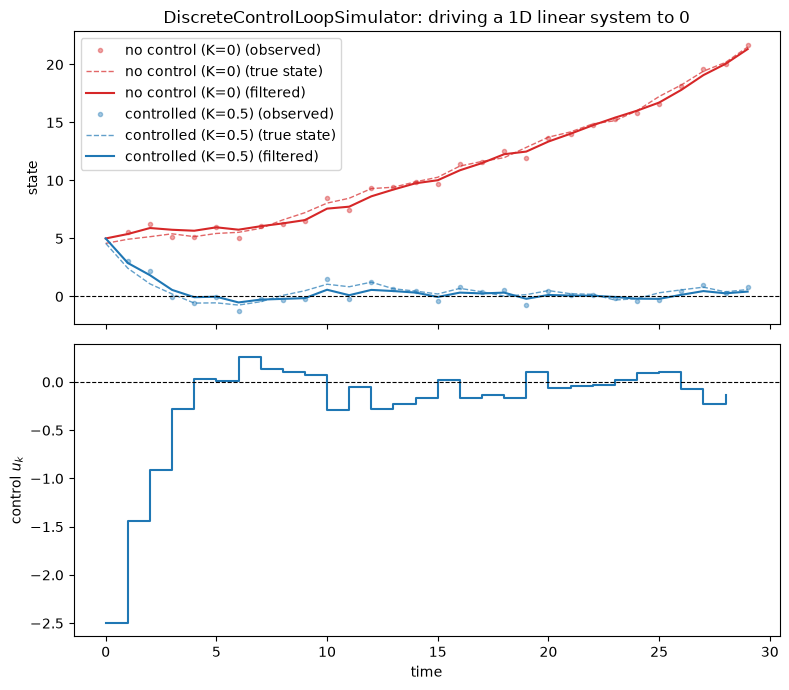

In [18]:
obs_times = result_controlled.obs_times[0]
ctrl_times = result_controlled.ctrl_times[0]
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

runs = [
    (result_uncontrolled, "no control (K=0)", "tab:red"),
    (result_controlled, "controlled (K=0.5)", "tab:blue"),
]
for result, label, color in runs:
    t = result.times[0]
    true_state = result.states[0, :, 0]
    obs = result.observations[0, :, 0]
    filtered_mean = result.filtered_states_mean[0, :, 0]
    axes[0].plot(obs_times, obs, ".", color=color, alpha=0.4, label=f"{label} (observed)")
    axes[0].plot(t, true_state, "--", color=color, alpha=0.7, linewidth=1, label=f"{label} (true state)")
    axes[0].plot(t, filtered_mean, "-", color=color, label=f"{label} (filtered)")

axes[0].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("state")
axes[0].legend()
axes[0].set_title("DiscreteControlLoopSimulator: driving a 1D linear system to 0")



u = result_controlled.controls[0, :, 0]
axes[1].step(ctrl_times, u, where="post", color="tab:blue")
axes[1].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("control $u_k$")
axes[1].set_xlabel("time")

plt.tight_layout()
plt.show()

## 5. A random controller

We may also define the policy $\pi$ to be stochastic. In this case, its initial state contains a PRNG key distinct from the key passed to the simulator. At each call, we split that key and update the policy state.

Here the gain itself is random, $K \sim \mathrm{Exponential}(\lambda)$, so $u \sim -K\hat{x}$ is sampled from this distribution.

In [16]:
class RandomPolicy(eqx.Module):
    rate: float
    init_key: jax.Array

    def __init__(self, rate, key):
        self.rate = rate
        self.init_key = key

    def initial_state(self): # here the policy uses the state to store key for randomness. We implement a convenient method to return the initial key.
        """Now returns the initial key for the randomness."""
        return self.init_key

    def __call__(self, x_hat, t_now, t_next, s):
        x = x_hat.mean
        K_dist = dist.Exponential(rate=self.rate)
        u_dist = dist.TransformedDistribution(
            K_dist, dist.transforms.AffineTransform(0.0, -x)
        )
        key, next_key = jr.split(s)
        u = u_dist.sample(key)
        return u, next_key

In [17]:
def run_random(rate, key):
    key, subkey = jr.split(key)
    policy = RandomPolicy(rate=rate, key=subkey)
    policy_state = policy.initial_state()  # get the initial key for the randomness
    return dsx.simulate(
        dynamics,
        rng_key=key,
        predict_times=predict_times,
        control_policy=policy,
        filter_config=KFConfig(filter_source="cuthbert", record_filtered_states_mean=True),
        initial_policy_state=policy_state # now we need to initialize the policy state with the initial key for randomness
    )


# rate=2.0 -> E[K] = 0.5, the same stabilizing gain used in Section 3.
result_random = run_random(rate=2.0, key=jr.PRNGKey(0))

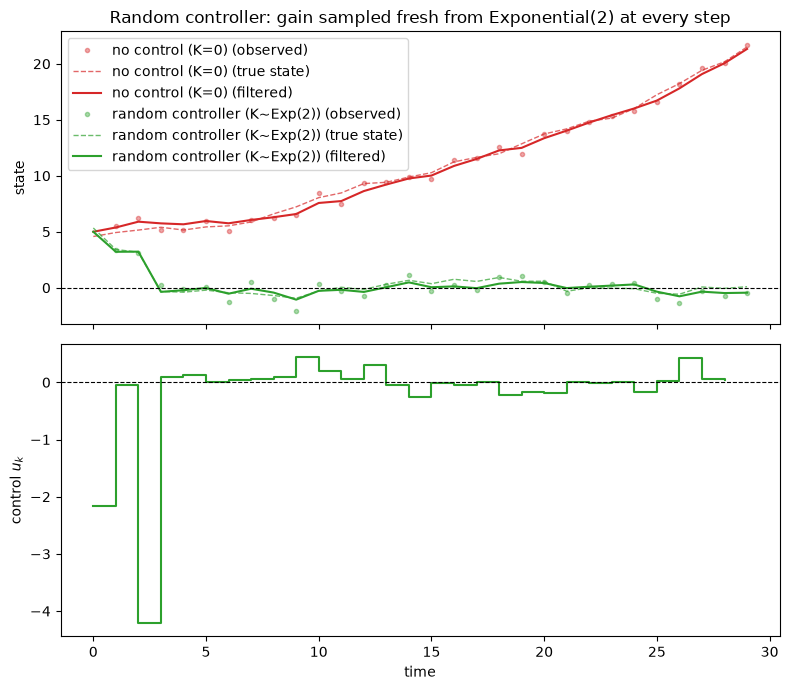

In [19]:
obs_times = result_random.obs_times[0]
ctrl_times = result_random.ctrl_times[0]
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

runs = [
    (result_uncontrolled, "no control (K=0)", "tab:red"),
    (result_random, "random controller (K~Exp(2))", "tab:green"),
]
for result, label, color in runs:
    t = result.times[0]
    true_state = result.states[0, :, 0]
    obs = result.observations[0, :, 0]
    filtered_mean = result.filtered_states_mean[0, :, 0]
    axes[0].plot(obs_times, obs, ".", color=color, alpha=0.4, label=f"{label} (observed)")
    axes[0].plot(t, true_state, "--", color=color, alpha=0.7, linewidth=1, label=f"{label} (true state)")
    axes[0].plot(t, filtered_mean, "-", color=color, label=f"{label} (filtered)")

axes[0].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("state")
axes[0].legend()
axes[0].set_title("Random controller: gain sampled fresh from Exponential(2) at every step")


u = result_random.controls[0, :, 0]
axes[1].step(ctrl_times, u, where="post", color="tab:green")
axes[1].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("control $u_k$")
axes[1].set_xlabel("time")

plt.tight_layout()
plt.show()

## 6. A black-box, partially-observed nonlinear SDE

So far the dynamics were already discrete-time. Here we go further: the control loop's
transition $p(x_{k+1} \mid x_k, u_k, t_k, t_{k+1})$ is allowed to be *any* black-box callable `(x, u, t_now, t_next) -> p(. | x, u, t_now, t_next)` returning either a NumPyro distribution or a bare black-box object exposing only `.sample(key)/.shape()`.

Here we integrate a genuine SDE with many small sub-steps between observations, and
`DiscreteControlLoopSimulator` never sees anything but the discrete grid. We consider a 2-d dynamical system $x_t \in \mathbb{R}^2$ obeying
$$
\begin{aligned}
dx_t &= A x_t^2 + u_t + \sigma\, dW_t \\
x_{t_k} &= x_{t_{k-1}} + \int_{t_{k-1}}^{t_k} Ax_s^2 + u_s ds + \sigma\int_{t_{k-1}}^{t_k}dW_s
\\
y_{t_k} &= H x_{t_k} + \eta_{t_k}
\end{aligned}
$$
with $A = \begin{pmatrix} 0.025 & 0.01 \\ 0.01 & 0.025 \end{pmatrix}$ (mild coupling, so that
observing $x_1$ is actually informative about $x_2$) and $H = \begin{pmatrix} 1 & 0
\end{pmatrix}$ (i.e. we only observe the first component). The discrete time dynamics are given by the continuous dynamics at discrete time $t_k = \Delta t k$. 

Two consequences of these changes:

- **The transition has no closed form.** A composition of many small nonlinear
  Euler-Maruyama steps is not Gaussian, so `KFConfig`/`EKFConfig` (which need a linearizable
  one-step Gaussian transition) don't apply. We use a **particle filter** (`PFConfig`)
  instead, and check below that an **ensemble Kalman filter** (`EnKFConfig`) works too.
- **$x_2$ is only observed indirectly**, through its dynamical coupling to $x_1$ via $A$'s
  off-diagonal terms.

In [20]:
from dynestyx.inference.configs.filter import EnKFConfig, PFConfig
from dynestyx.models import FullDiffusion

state_dim_2d = control_dim_2d = 2
obs_dim_2d = 1
A = jnp.array([[0.025, 0.01], [0.01, 0.025]])
sigma_2d = 0.1

Wrapping its output in a small `.sample(key)` / `.shape()` object turns it into a discrete-time
`state_evolution` the control loop can call without knowing anything happens in between. This is a genuine black box, only usable with filters
(PF, EnKF) that only need to *sample* the transition. The control is held constant
(zero-order hold) across the sub-steps via `control_path_eval`.

In [21]:
from dynestyx.models import StochasticContinuousTimeStateEvolution
from dynestyx.solvers import euler_maruyama_integrate_state_to_time

substep_dt = 0.02  # ~5 EM sub-steps per 0.1-spaced observation interval

cte = StochasticContinuousTimeStateEvolution(
    drift=lambda x, u, t: A @ (x**2) + u,
    diffusion=FullDiffusion(sigma_2d * jnp.eye(state_dim_2d)),  # bm_dim inferred from the matrix shape
)


class SubSteppedSDEStep:
    """A single control-loop transition that is itself a sub-stepped SDE
    integration -- the simulator only ever sees `.sample()`/`.shape()`,
    exactly as it would for e.g. a MuJoCo step."""

    def __init__(self, cte, x_prev, u, t_now, t_next, *, dt0):
        self._cte, self._x_prev, self._u = cte, x_prev, u
        self._t_now, self._t_next, self._dt0 = t_now, t_next, dt0

    def sample(self, key):
        x_out, _, _ = euler_maruyama_integrate_state_to_time(
            self._cte,
            self._x_prev,
            self._t_now,
            key,
            self._t_next,
            dt0=self._dt0,
            control_path_eval=lambda t: self._u,
        )
        return x_out

    def shape(self):
        return self._x_prev.shape


def black_box_sde_transition(x, u, t_now, t_next): # A black-box function that wraps the SDE transition.
    return SubSteppedSDEStep(cte, x, u, t_now, t_next, dt0=substep_dt)


In general, a Dynamical model takes the following arguments
- **`initial_condition`**: any `numpyro.distributions.Distribution` — `.sample(key) -> x_0`.
- **`state_evolution`**: `(x, u, t_now, t_next) -> obj`, `obj.sample(key) -> x_next`. Real `Distribution` needed for `KFConfig`/`EKFConfig` (`.mean`); bare `.sample(key)`/`.shape()` suffices for `PFConfig`/`EnKFConfig`.
- **`observation_model`**: `(x, u, t) -> obj`, `obj.sample(key) -> y`, always a real `Distribution`, no black-box-only path: `.mean` for `KFConfig`/`EKFConfig`, Gaussian (extractable covariance) for `EnKFConfig`, any `.log_prob`-bearing `Distribution` for `PFConfig`.
- **`control_dim`**: plain `int`, defaults to `0`.

In [22]:
nonlinear_dynamics = DynamicalModel(
    initial_condition=dist.MultivariateNormal(
        jnp.array([3.0, 2.0]), 0.05 * jnp.eye(state_dim_2d)), #can be replaced with any numpyro distribution
    state_evolution=black_box_sde_transition,
    observation_model=LinearGaussianObservation(
        H=jnp.eye(obs_dim_2d, state_dim_2d), R=0.05 * jnp.eye(obs_dim_2d)
    ),
    control_dim=control_dim_2d,
)

The controller is the same `LinearPolicy` as before, with a $2\times2$ gain $K = k \cdot I$. The case 
$k=0$ reproduces the uncontrolled (unstable) system. 

In [23]:
predict_times_2d = jnp.arange(0.0, 6.0, 0.1)


def run_2d(k: float, key, filter_config):
    policy = LinearPolicy(K=k * jnp.eye(control_dim_2d))
    return dsx.simulate(
        nonlinear_dynamics,
        rng_key=key,
        predict_times=predict_times_2d,
        control_policy=policy,
        filter_config=filter_config,
    )


pf_config = PFConfig(n_particles=500, record_filtered_states_mean=True)
# pf_config = EnKFConfig(n_particles=500, record_filtered_states_mean=True)  # You can also try the EnKF.

key_2d = jr.PRNGKey(0)
result_pf_controlled = run_2d(k=1.0, key=key_2d, filter_config=pf_config)
result_pf_uncontrolled = run_2d(k=0.0, key=key_2d, filter_config=pf_config)

/Users/matthieu/Documents/GitHub/dynestyx/dynestyx/simulation/auto.py:320: UserWarning: dynamics.observation_control_alignment is unspecified; closed-loop control uses 'previous_transition'. Set it explicitly on the model to silence this warning.
  return simulator.simulate(


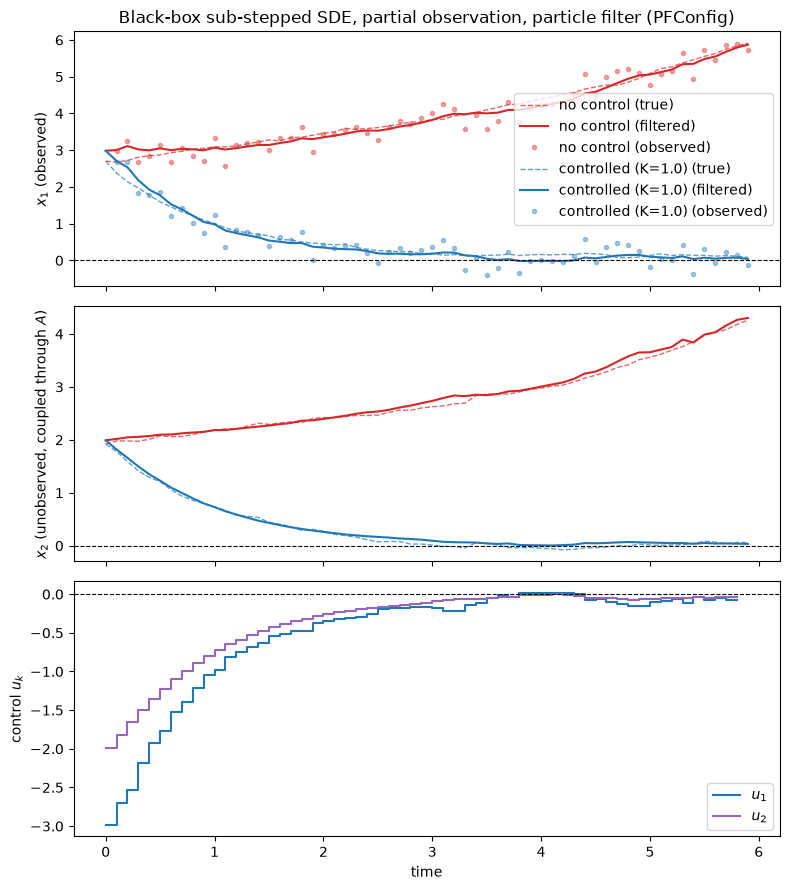

In [24]:
obs_times = result_pf_controlled.obs_times[0]
ctrl_times = result_pf_controlled.ctrl_times[0]
def plot_2d_runs(runs, controlled_result, title):
    fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

    for result, label, color in runs:
        t = result.times[0]
        true_state = result.states[0]
        filtered_mean = result.filtered_states_mean[0]
        axes[0].plot(t, true_state[:, 0], "--", color=color, alpha=0.7, linewidth=1, label=f"{label} (true)")
        axes[0].plot(t, filtered_mean[:, 0], "-", color=color, label=f"{label} (filtered)")
        axes[0].plot(t[1:], result.observations[0][:, 0], ".", color=color, alpha=0.4, label=f"{label} (observed)")
        axes[1].plot(t, true_state[:, 1], "--", color=color, alpha=0.7, linewidth=1)
        axes[1].plot(t, filtered_mean[:, 1], "-", color=color)

    axes[0].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
    axes[0].set_ylabel("$x_1$ (observed)")
    axes[0].legend()
    axes[0].set_title(title)

    axes[1].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
    axes[1].set_ylabel("$x_2$ (unobserved, coupled through $A$)")

    t_u = controlled_result.times[0][:-1]
    u = controlled_result.controls[0]
    axes[2].step(t_u, u[:, 0], where="post", color="tab:blue", label="$u_1$")
    axes[2].step(t_u, u[:, 1], where="post", color="tab:purple", label="$u_2$")
    axes[2].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
    axes[2].set_ylabel("control $u_k$")
    axes[2].set_xlabel("time")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


plot_2d_runs(
    [
        (result_pf_uncontrolled, "no control", "tab:red"),
        (result_pf_controlled, "controlled (K=1.0)", "tab:blue"),
    ],
    result_pf_controlled,
    "Black-box sub-stepped SDE, partial observation, particle filter (PFConfig)",
)